In [1]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import pretty_midi
from tqdm import tqdm

warnings.filterwarnings("ignore")

FS = 20
LOW_PITCH = 21
HIGH_PITCH = 108
N_PITCHES = HIGH_PITCH - LOW_PITCH + 1

SEQ_LEN = 256
HOP_LEN = 128
BINARIZE = True
MAX_FILES_PER_SPLIT = None


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / "data" / "raw_midi" / "maestro-v3.0.0.csv").exists():
            return c
    raise FileNotFoundError("Could not find repo root containing data/raw_midi/maestro-v3.0.0.csv")

CWD = Path.cwd()
ROOT = find_repo_root(CWD)

CSV_PATH = ROOT / "data" / "raw_midi" / "maestro-v3.0.0.csv"
MIDI_ROOT = ROOT / "data" / "raw_midi"
OUT_DIR = ROOT / "data" / "processed" / "pianoroll_chunks"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("CWD:", CWD)
print("ROOT:", ROOT)
print("CSV_PATH exists:", CSV_PATH.exists())
print("MIDI_ROOT exists:", MIDI_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

CWD: g:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\notebooks
ROOT: g:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-
CSV_PATH exists: True
MIDI_ROOT exists: True
OUT_DIR: g:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\data\processed\pianoroll_chunks


In [3]:
df = pd.read_csv(CSV_PATH)

required_cols = [
    "canonical_composer",
    "canonical_title",
    "split",
    "year",
    "midi_filename",
    "duration",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in metadata: {missing_cols}")

df["midi_path"] = df["midi_filename"].apply(lambda rel: MIDI_ROOT / rel)
df["exists"] = df["midi_path"].apply(lambda p: p.exists())

print("Rows in CSV:", len(df))
print("Rows with existing midi file:", int(df["exists"].sum()))
print("Rows missing file:", int((~df["exists"]).sum()))
print("\nSplit counts:")
print(df["split"].value_counts(dropna=False))

df = df[df["exists"]].reset_index(drop=True)
df.head(3)

Rows in CSV: 1276
Rows with existing midi file: 1276
Rows missing file: 0

Split counts:
split
train         962
test          177
validation    137
Name: count, dtype: int64


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration,midi_path,exists
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160,g:\Unsupervised-Neural-Network-for-Multi-Genre...,True
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471,g:\Unsupervised-Neural-Network-for-Multi-Genre...,True
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433,g:\Unsupervised-Neural-Network-for-Multi-Genre...,True


In [4]:
def midi_to_roll(
    midi_path: Path,
    fs: int = FS,
    low_pitch: int = LOW_PITCH,
    high_pitch: int = HIGH_PITCH,
    binarize: bool = BINARIZE,
):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    roll = pm.get_piano_roll(fs=fs)
    roll = roll[low_pitch:high_pitch + 1]
    roll = roll.T

    if binarize:
        roll = (roll > 0).astype(np.float32)
    else:
        roll = np.clip(roll / 127.0, 0.0, 1.0).astype(np.float32)

    return roll


def chunk_roll(roll: np.ndarray, seq_len: int = SEQ_LEN, hop_len: int = HOP_LEN):
    if roll.shape[0] == 0:
        return [], []

    if roll.shape[0] < seq_len:
        padded = np.zeros((seq_len, roll.shape[1]), dtype=np.float32)
        padded[:roll.shape[0]] = roll
        return [padded], [roll.shape[0]]

    chunks = []
    lengths = []

    for start in range(0, roll.shape[0] - seq_len + 1, hop_len):
        chunk = roll[start:start + seq_len]
        chunks.append(chunk)
        lengths.append(seq_len)

    last_start = roll.shape[0] - seq_len
    if len(chunks) == 0 or (last_start % hop_len != 0):
        chunk = roll[last_start:last_start + seq_len]
        chunks.append(chunk)
        lengths.append(seq_len)

    return chunks, lengths

In [5]:
SHARD_CHUNK_LIMIT = 8000  # keep each shard comfortably below file-size limits


def preprocess_split(split_name: str, table: pd.DataFrame, shard_chunk_limit: int = SHARD_CHUNK_LIMIT):
    split_df = table[table["split"] == split_name].reset_index(drop=True)

    if MAX_FILES_PER_SPLIT is not None:
        split_df = split_df.iloc[:MAX_FILES_PER_SPLIT].copy()

    x_paths = []
    lengths_paths = []
    records = []

    chunk_buffer = []
    length_buffer = []
    record_buffer = []

    total_chunks = 0
    skipped = 0
    shard_idx = 0

    def flush_shard():
        nonlocal chunk_buffer, length_buffer, record_buffer
        nonlocal total_chunks, shard_idx

        if not chunk_buffer:
            return

        x_arr = np.stack(chunk_buffer).astype(np.float16)
        lengths_arr = np.asarray(length_buffer, dtype=np.int32)

        x_path = OUT_DIR / f"{split_name}_x_shard_{shard_idx:03d}.npy"
        lengths_path = OUT_DIR / f"{split_name}_lengths_shard_{shard_idx:03d}.npy"

        np.save(x_path, x_arr)
        np.save(lengths_path, lengths_arr)

        for local_idx, rec in enumerate(record_buffer):
            rec["shard_idx"] = int(shard_idx)
            rec["local_chunk_idx"] = int(local_idx)
            records.append(rec)

        x_paths.append(str(x_path))
        lengths_paths.append(str(lengths_path))
        total_chunks += len(x_arr)

        shard_idx += 1
        chunk_buffer = []
        length_buffer = []
        record_buffer = []

    iterator = tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name}")
    for row_idx, row in iterator:
        midi_path = row["midi_path"]

        try:
            roll = midi_to_roll(midi_path)
            chunks, chunk_lengths = chunk_roll(roll)

            for ci, (ch, ln) in enumerate(zip(chunks, chunk_lengths)):
                chunk_buffer.append(ch)
                length_buffer.append(ln)
                record_buffer.append({
                    "split": split_name,
                    "source_row_index": int(row_idx),
                    "composer": row["canonical_composer"],
                    "title": row["canonical_title"],
                    "year": int(row["year"]) if pd.notna(row["year"]) else None,
                    "midi_filename": row["midi_filename"],
                    "chunk_index": int(ci),
                    "valid_length": int(ln),
                    "seq_len": int(SEQ_LEN),
                })

                if len(chunk_buffer) >= shard_chunk_limit:
                    flush_shard()

        except Exception as exc:
            skipped += 1
            print(f"Skipping {midi_path}: {exc}")

    flush_shard()

    if total_chunks == 0:
        print(f"No chunks produced for split={split_name}")
        return None

    meta_path = OUT_DIR / f"{split_name}_meta.csv"
    stats_path = OUT_DIR / f"{split_name}_stats.json"

    meta = pd.DataFrame(records)
    meta.to_csv(meta_path, index=False)

    stats = {
        "split": split_name,
        "n_files": int(len(split_df)),
        "n_chunks": int(total_chunks),
        "shape_per_chunk": [int(SEQ_LEN), int(N_PITCHES)],
        "dtype": "float16",
        "n_shards": int(len(x_paths)),
        "skipped_files": int(skipped),
        "x_paths": x_paths,
        "lengths_paths": lengths_paths,
        "meta_path": str(meta_path),
    }

    with open(stats_path, "w", encoding="utf-8") as f:
        json.dump(stats, f, indent=2)

    return {
        "split": split_name,
        "x_paths": x_paths,
        "lengths_paths": lengths_paths,
        "meta_path": str(meta_path),
        "stats_path": str(stats_path),
        "stats": stats,
    }


train_data = preprocess_split("train", df)
val_data = preprocess_split("validation", df)
test_data = preprocess_split("test", df)

for item in [train_data, val_data, test_data]:
    if item is None:
        continue
    s = item["stats"]
    print(f"{s['split']}: chunks={s['n_chunks']} shards={s['n_shards']} dtype={s['dtype']}")

Processing test: 100%|██████████| 177/177 [00:31<00:00,  5.70it/s]


train: chunks=89227 shards=12 dtype=float16
validation: chunks=10883 shards=2 dtype=float16
test: chunks=11179 shards=2 dtype=float16


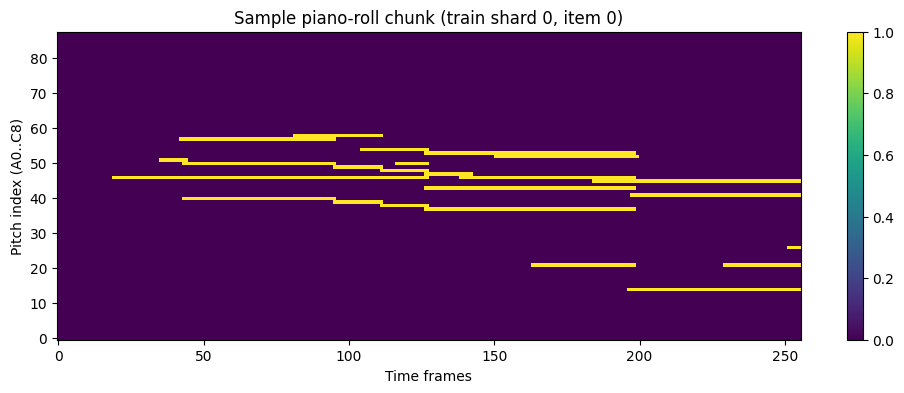

In [6]:
import matplotlib.pyplot as plt

if train_data is not None and len(train_data["x_paths"]) > 0:
    train_x_mm = np.load(train_data["x_paths"][0], mmap_mode="r")
    if len(train_x_mm) > 0:
        sample = np.asarray(train_x_mm[0], dtype=np.float32).T
        plt.figure(figsize=(12, 4))
        plt.imshow(sample, aspect="auto", origin="lower", interpolation="nearest")
        plt.title("Sample piano-roll chunk (train shard 0, item 0)")
        plt.xlabel("Time frames")
        plt.ylabel("Pitch index (A0..C8)")
        plt.colorbar()
        plt.show()

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class ShardedPianoRollDataset(Dataset):
    def __init__(self, x_paths, lengths_paths):
        self.x_shards = [np.load(p, mmap_mode="r") for p in x_paths]
        self.len_shards = [np.load(p) for p in lengths_paths]

        self.shard_sizes = [len(x) for x in self.x_shards]
        self.offsets = np.cumsum([0] + self.shard_sizes)

    def __len__(self):
        return int(self.offsets[-1])

    def __getitem__(self, idx):
        shard_idx = int(np.searchsorted(self.offsets, idx, side="right") - 1)
        local_idx = int(idx - self.offsets[shard_idx])

        x = torch.tensor(np.asarray(self.x_shards[shard_idx][local_idx], dtype=np.float32), dtype=torch.float32)
        length = torch.tensor(int(self.len_shards[shard_idx][local_idx]), dtype=torch.long)
        return x, x, length

if train_data is not None:
    train_dataset = ShardedPianoRollDataset(train_data["x_paths"], train_data["lengths_paths"])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    bx, by, bl = next(iter(train_loader))
    print("Batch x:", bx.shape, "Batch lengths:", bl.shape)
    print("Dataset size:", len(train_dataset))

Batch x: torch.Size([32, 256, 88]) Batch lengths: torch.Size([32])
Dataset size: 89227
